1. Implement a simple GRU cell from scratch in Python using only NumPy, focusing on the update and reset gates — given input x_t and previous hidden state h_{t-1}, compute the next hidden state h_t.


In [1]:
import numpy as np

# Sigmoid Function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Tanh Function
def tanh(x):
    return np.tanh(x)

# GRU Cell
def gru_cell(x_t, h_prev):

    # Weights
    Wz = 0.5
    Uz = 0.3

    Wr = 0.4
    Ur = 0.2

    Wh = 0.6
    Uh = 0.5

    # Biases
    bz = 0.1
    br = 0.1
    bh = 0.1

    # Update Gate
    z = sigmoid(Wz * x_t + Uz * h_prev + bz)

    # Reset Gate
    r = sigmoid(Wr * x_t + Ur * h_prev + br)

    # Candidate Hidden State
    h_candidate = tanh(Wh * x_t + Uh * (r * h_prev) + bh)

    # Final Hidden State
    h = (1 - z) * h_prev + z * h_candidate

    return h, z, r


# Example
sequence = [10, 20, 15, 18, 25]

h = 0

for x in sequence:

    h, z, r = gru_cell(x, h)

    print(f"Input={x}")
    print(f"Update Gate={z:.4f}")
    print(f"Reset Gate={r:.4f}")
    print(f"Hidden State={h:.4f}")
    print("----------------------")

Input=10
Update Gate=0.9939
Reset Gate=0.9837
Hidden State=0.9939
----------------------
Input=20
Update Gate=1.0000
Reset Gate=0.9998
Hidden State=1.0000
----------------------
Input=15
Update Gate=0.9996
Reset Gate=0.9982
Hidden State=1.0000
----------------------
Input=18
Update Gate=0.9999
Reset Gate=0.9994
Hidden State=1.0000
----------------------
Input=25
Update Gate=1.0000
Reset Gate=1.0000
Hidden State=1.0000
----------------------


2. Given a code snippet of an LSTM cell and a GRU cell, write a comparison table listing at least 3 ways in which the GRU architecture simplifies the LSTM, focusing on the number of gates, parameters, and information flow.

Explanation

GRU simplifies LSTM by:

Using 2 gates instead of 3
Removing the separate cell state
Using fewer parameters, making training faster

3. Visualize the update and reset gate activations for a GRU layer on a sample sequence (e.g., a list of song ratings over time from Spotify) using matplotlib — plot the gate values for each time step.

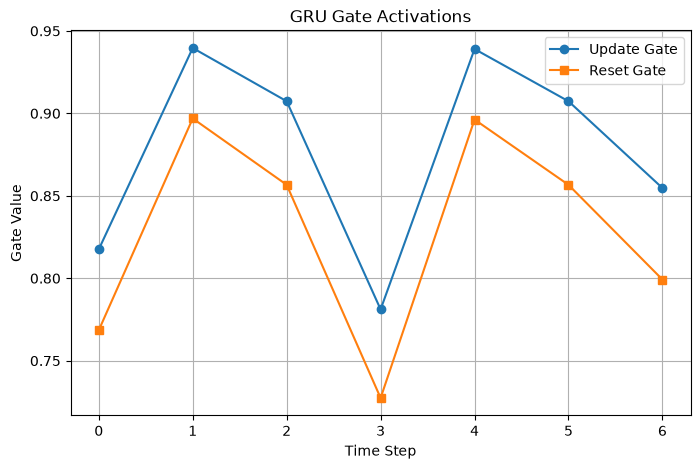

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1/(1+np.exp(-x))

# Spotify Song Ratings
ratings = [3,5,4,2,5,4,3]

update_gate = []
reset_gate = []

h = 0

for x in ratings:

    z = sigmoid(0.5*x + 0.3*h)

    r = sigmoid(0.4*x + 0.2*h)

    update_gate.append(z)

    reset_gate.append(r)

    h = z

plt.figure(figsize=(8,5))

plt.plot(update_gate, marker='o', label="Update Gate")

plt.plot(reset_gate, marker='s', label="Reset Gate")

plt.title("GRU Gate Activations")

plt.xlabel("Time Step")

plt.ylabel("Gate Value")

plt.legend()

plt.grid(True)

plt.show()

4. Build a small Keras model with a single GRU layer to predict the next value in a sequence of daily step counts (you can generate random data). Train it for 10 epochs and report the training time and final loss.<br><br><em><strong>Hint:</strong> Compare the training time to a similar LSTM model if possible.</em>

In [3]:
import numpy as np
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import Dense

# Random Daily Steps
steps = np.random.randint(4000,9000,100)

# Prepare Dataset
X = []
y = []

sequence_length = 5

for i in range(len(steps)-sequence_length):

    X.append(steps[i:i+sequence_length])

    y.append(steps[i+sequence_length])

X = np.array(X)

y = np.array(y)

# Reshape for GRU
X = X.reshape((X.shape[0], X.shape[1],1))

# Build Model
model = Sequential()

model.add(
    GRU(
        32,
        input_shape=(sequence_length,1)
    )
)

model.add(Dense(1))

# Compile
model.compile(
    optimizer='adam',
    loss='mse'
)

# Training Time
start = time.time()

history = model.fit(
    X,
    y,
    epochs=10,
    batch_size=8,
    verbose=1
)

end = time.time()

print("\nTraining Time:", round(end-start,2),"seconds")

print("Final Loss:", history.history["loss"][-1])

c:\Users\tejal\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 45089332.0000
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 45085496.0000 
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45082824.0000 
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45080140.0000 
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45077460.0000 
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45074816.0000 
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 45072132.0000 
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 45069468.0000 
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45066800.0000 
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 45064132.0000 

Training Time: 5.61 seconds
Final Loss: 45064132.0
